<a href="https://colab.research.google.com/github/Diego-Sarinana/telecom-analysis/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

## Objetivo
Evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Se trabajó con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se trabajó con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

El proceso llevado fue de **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis hace posible **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.



---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarse con la estructura de los tres datasets**.  
En esta etapa, se validó que los archivos se carguen correctamente, se conocieron sus columnas y tipos de datos, y se detectaron posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Pasos:**  
- Se importan las librerías necesarias (`pandas`, `seaborn`, `matplotlib.pyplot`).
- Carga de archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Se guardan los DataFrames en las variables: `plans`, `users` y `usage` para un mejor manejo y legibilidad.
- Se muestran las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Pasos:**  
- Revisión de **número de filas y columnas** de cada dataset usando `.shape`.  
- Uso de `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Pasos:**  
- Conteo de valores nulos por columna para cada dataset.
- Se calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.


In [ ]:
# cantidad de nulos para users
users_null = users.isna().sum()
users_mean = users.isna().mean()
print("Cantidad de valores nulos:\n", users_null)
print("Proporción de valores nulos:\n", users_mean)

Cantidad de valores nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
usage_null = usage.isna().sum()
usage_mean = usage.isna().mean()
print("Cantidad de valores nulos:\n", usage_null)
print("Proporción de valores nulos:\n", usage_mean)

Cantidad de valores nulos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



 **Diagnóstico Del Bloque**

 ---

**Valores nulos**  
1. ¿Qué columnas tienen valores faltantes y en qué proporción?
2. Procedimiento: ¿imputar, eliminar, ignorar?

- En Users encontramos que city y churn_date tienen nulos (11% y 88% en proporción respectivamente), se sugiere ignorar churn_date pues la mayoría de usuarios están activos e investigar los datos de city para imputar o dejar como nulos.
- En Usage se sugiere la imputación en date (proporción 0.1%) ya que pudiera ser relevante incluir las fechas y para duration y length (proporción 55% y 44%, respectivamente) ignorarlas pues varia si es call o text por lo que no es posible en algunos casos obtener esos datos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Procedimiento:**
- Exploración de las columnas numéricas con **un resumen estadístico** y descripción breve de los hallazgos.
- Exploración de las columnas categóricas **relevantes**, revisión de sus valores únicos y descripción breve de hallazgos.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


- La columna `user_id` incluye 4000 usuarios únicos sin sentinels.
- La columna `age` incluye valores inválidos pues el mínimo no puede ser -999 lo que altera los resultados.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`incluyen los 4000 usuarios únicos registrados.
- Las columnas 'duration' y 'length' tienen sesgo a la derecha pues los datos máximos están más alejados de la mediana que los datos mínimos.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` muestra que Bogotá es la ciudad con la mayor cantidad de usuarios.
- La columna `plan` nos indica que el plan básico es el más contratado

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` revela que se hace un mayor uso de mensajes de texto que de llamadas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- En la columna age de users encontré valores inválidos (-999) por lo que hay que reemplazarlos con la mediana.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce", utc=True)

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce",utc=True)

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`encontramos datos del 2022 al 2024 pero datos fuera de lugar del año 2026

In [ ]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.unique()

array([2024.,   nan])

En `date`, encontramos datos de "2024." lo que requiere una corrección y valores nulos(nan)
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Aparece el año 2026 que está fuera del rango de datos trabajados, lo que implica investigar para reemplazar o dejar como nulos los datos con ésta fecha y el año "2024." que requiere limpieza ya que el punto está de más y afecta el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
numeric_sentinel = -999
users['age'] = users["age"].replace(numeric_sentinel, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
(users["city"] == "?").sum()

0

In [ ]:
# Marcar fechas futuras como NA para reg_date
users[users["reg_date"].dt.year == 2026] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

In [ ]:
users["reg_date"].value_counts()

2023-12-20 18:33:45.506376600+00:00    1
2024-12-31 00:00:00+00:00              1
2024-09-19 14:12:19.984996256+00:00    1
2024-06-20 09:50:54.463615904+00:00    1
2022-05-22 00:23:45.956489122+00:00    1
                                      ..
2022-09-25 05:55:24.531132784+00:00    1
2022-07-29 04:44:06.661665416+00:00    1
2022-02-22 00:36:43.750937734+00:00    1
2022-10-31 09:22:49.242310580+00:00    1
2022-03-28 12:38:20.975243811+00:00    1
Name: reg_date, Length: 3960, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

En `duration`y`length` se dejan los nulos ya que los mensajes de texto no tienen duration sino length y viceversa para las llamadas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(
    users,
    on='user_id',
    how='left'
)
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
usage_columns = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]
user_profile[usage_columns].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
plan_percentages = user_profile['plan'].value_counts(normalize=True) * 100
print(plan_percentages)

Basico     64.9659
Premium    35.0341
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

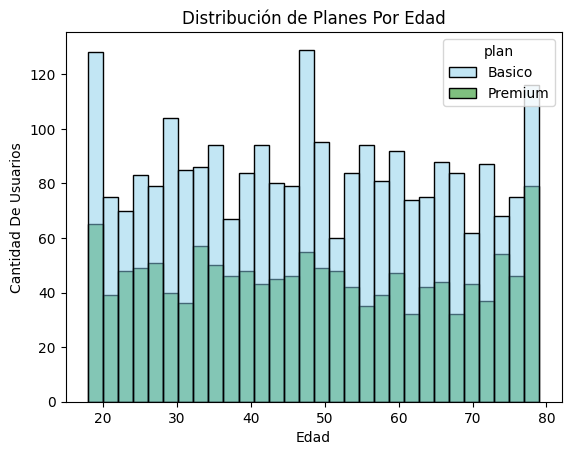

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(x=user_profile["age"],hue=user_profile['plan'],palette=['skyblue','green'],alpha=0.5, bins=30, multiple="layer")
plt.xlabel("Edad")
plt.ylabel("Cantidad De Usuarios")
plt.title("Distribución de Planes Por Edad")
plt.show()

💡Insights: Se hallaron datos sobresalientes sobre las edades aproximadas de 18, 48 y 78 que indican mejores clientes alrededor de esas edades especialmente alrededor de los 78 pues es donde hay mayor cantidad de usuarios que contratan el plan premium, se sugiere aumentar las ofertas y/o beneficios para esos clientes 'premium'.
- Distribución: se observa simetría por alta dispersión sin sesgo.

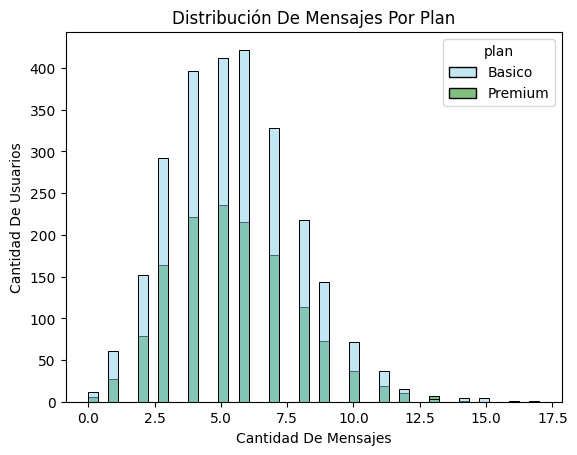

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(x=user_profile["cant_mensajes"],hue=user_profile['plan'],palette=['skyblue','green'])
plt.xlabel("Cantidad De Mensajes")
plt.ylabel("Cantidad De Usuarios")
plt.title("Distribución De Mensajes Por Plan")
plt.show()


💡Insights: la mayor concentración se encuentra en 5 mensajes al día con casi 250 usuarios en este rango en su mayoría en plan premium.
- Tenemos una distribución con sesgo a la derecha en el que probablemente haya outliers o usuarios específicos que hacen mayor uso de los mensajes.

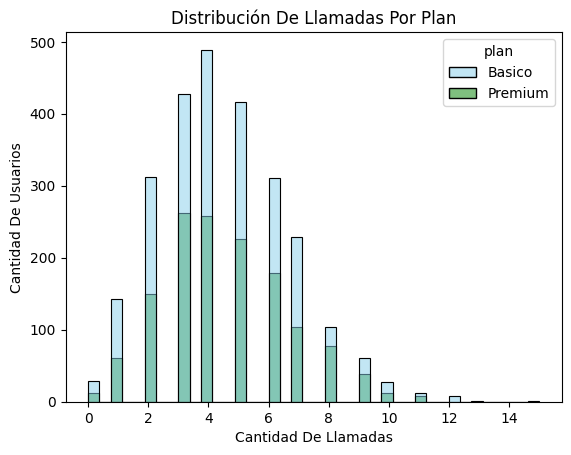

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(x=user_profile["cant_llamadas"],hue=user_profile['plan'],palette=['skyblue','green'])
plt.xlabel("Cantidad De Llamadas")
plt.ylabel("Cantidad De Usuarios")
plt.title("Distribución De Llamadas Por Plan")
plt.show()


In [ ]:
user_profile["cant_llamadas"].describe()

count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

💡Insights: Los usuarios en su mayoría hacen entre 3 y 4 llamadas al día especialmente quienes tienen el plan premium, lo que indica un buen aprovechamiento del plan.
- Distribución con sesgo a la derecha debido a algunos usuarios que hacen hasta 15 llamadas.

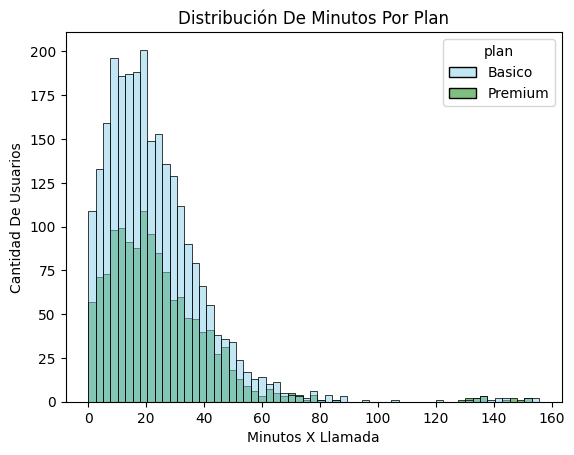

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(x=user_profile["cant_minutos_llamada"],hue=user_profile['plan'],palette=['skyblue','green'],alpha=0.5)
plt.xlabel("Minutos X Llamada")
plt.ylabel("Cantidad De Usuarios")
plt.title("Distribución De Minutos Por Plan")
plt.show()


In [ ]:
user_profile["cant_minutos_llamada"].describe()

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

💡Insights: Ambos planes tienen un uso similar entre los usuarios con mayor uso entre 10 y 20 minutos diarios.
- Tenemos un claro sesgo a la derecha con algunos probables outliers en el plan premium con datos de hasta 155 minutos por llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

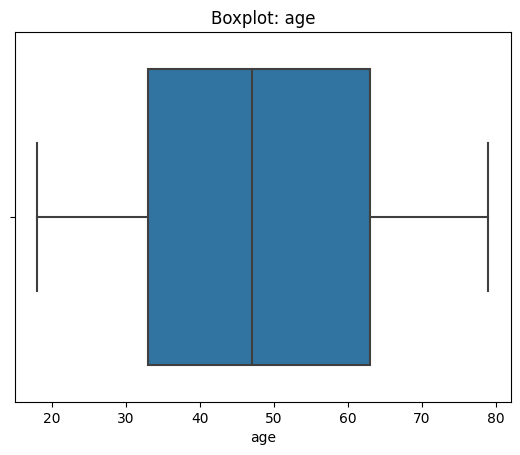

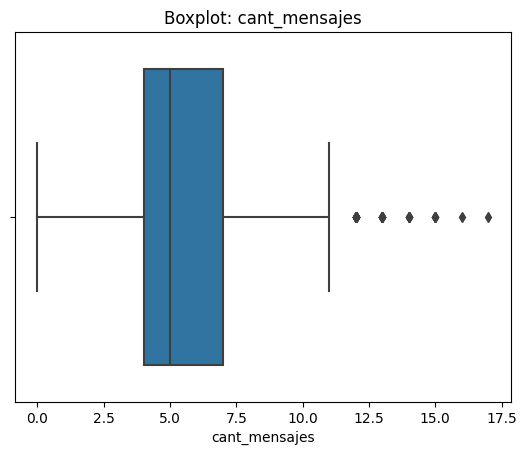

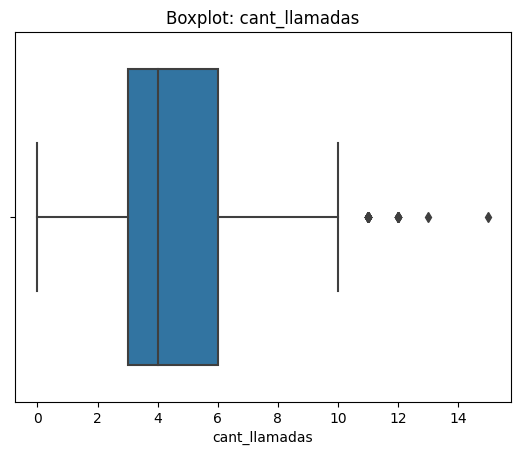

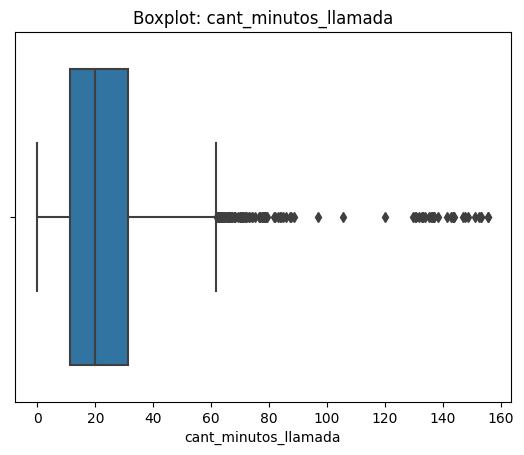

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:

    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Cuenta con 6 valores como outliers
- cant_llamadas: Tiene 4 valores outliers
- cant_minutos_llamada: Es el boxplot con mayor cantidad de outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    print(col)
    Q1 = user_profile[col].quantile(0.25)
    print('Primer Cuartil:',Q1)
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer Cuartil:',Q3)
    IQR = Q3 - Q1
    print('IQR:', IQR)
    upper = Q3 + 1.5 * IQR
    print('Límite Superior:', upper)
    print()



cant_mensajes
Primer Cuartil: 4.0
Tercer Cuartil: 7.0
IQR: 3.0
Límite Superior: 11.5

cant_llamadas
Primer Cuartil: 3.0
Tercer Cuartil: 6.0
IQR: 3.0
Límite Superior: 10.5

cant_minutos_llamada
Primer Cuartil: 11.12
Tercer Cuartil: 31.415
IQR: 20.295
Límite Superior: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener outliers pues a los usuarios que hacen mayor uso de los mensajes pudiera interesarles un paquete promocional acorde a su consumo de mensajes.
- cant_llamadas: mantener o no outliers, porqué? Mantener outliers porque nos revela que hay usuarios que usan más los servicios de la empresa por lo que se sugiere ofrecerles un paquete y/o servicio que les beneficie para no limitar y hasta aumentar su uso de las llamadas.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener outliers pues son datos importantes que indican que existen usuarios haciendo un mejor y mayor uso del servicio lo que si se aprovecha y se les incentiva pudieran llegar a ser un grupo especial que genere mayores ganancias.  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where((user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5), "Bajo Uso",
                                     np.where((user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10), "Uso Medio", "Alto Uso"))


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso Medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto Uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso Medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto Uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where((user_profile["age"] < 30), "Joven",
                                      np.where((user_profile["age"] < 60), "Adulto", "Adulto Mayor"))

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso Medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto Uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso Medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto Uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

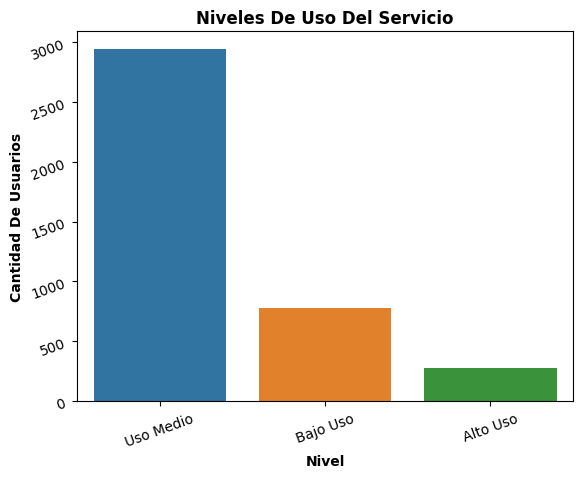

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", order=user_profile["grupo_uso"].value_counts().index)
plt.title("Niveles De Uso Del Servicio", fontweight='bold')
plt.xlabel("Nivel", fontweight='bold')
plt.ylabel("Cantidad De Usuarios", fontweight='bold')
plt.xticks(rotation=20)
plt.yticks(rotation=20)
plt.show()

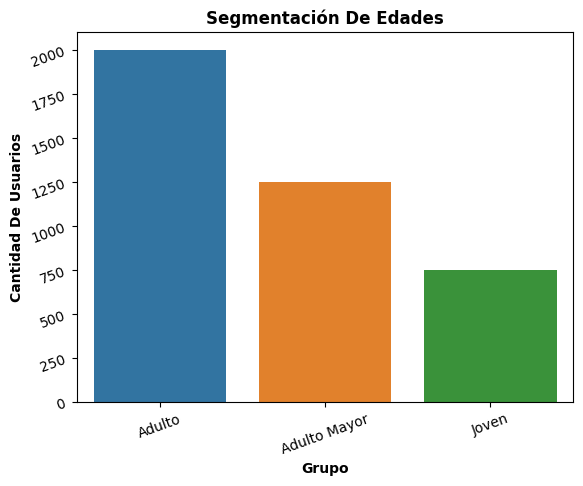

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", order=user_profile["grupo_edad"].value_counts().index)
plt.title("Segmentación De Edades", fontweight='bold')
plt.xlabel("Grupo", fontweight='bold')
plt.ylabel("Cantidad De Usuarios", fontweight='bold')
plt.xticks(rotation=20)
plt.yticks(rotation=20)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron algunos datos fuera del rango de fechas del dataset de 'Users' en los que habia datos con el año 2026.
- Hubo un total de 40 registros en la columna 'city' del dataset 'Users' en los que se escribió '?' y se convirtieron en NA.
- En la columna 'age' de 'Users' se encontraron valores invalidos -999 a los que se le imputó la mediana.


🔍 **Segmentos por Edad**
- Tenemos los segmentos 'Joven', 'Adulto' y 'Adulto Mayor' con mayor cantidad en 'Adulto' y un 'Uso Medio' mayor, lo que indica que la mayoría de los usuarios que son Adultos no le da un gran uso a su servicio lo que pudiera requerir incentivos para un mejor desempeño.


📊 **Segmentos por Nivel de Uso**
- Obtuvimos segmentos 'Bajo Uso', 'Uso Medio' y 'Alto Uso', teniendo el segmento 'Uso Medio' como el más alto y el 'Alto Uso' con el nivel más bajo lo que indica que el usuario promedio no le está dando uso suficiente a su servicio.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Se implementen mejoras en el servicio para que sea más atrayente para el usuario ya sea centrándose en la calidad de los servicios, la facilidad de uso y/o crear promociones para los usuarios actuales y atraer a nuevos.
- El servicio para los usuarios jovenes pudiera requerir ajustes ya que según los hallazgos no es lo suficientemente llamativo para los menores de 30 y se están perdiendo oportunidades de negocio, se recomienda llegar a éstos usuarios ofreciendo paquetes o promociones que les beneficie, agrade y se adapte a sus necesidades.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/Diego-Sarinana/telecom-analysis`